In [314]:
import binascii
import pandas as pd
import re
import io
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
%run ../Framework/ADLSClient.ipynb

In [3]:
month = 'jan'
state = 'tx'

In [182]:
adls_client = ADLSClient()
container_client = adls_client.create_container_client()

#regex_str = fr"(?i)^fhwa_import/.*({state}.*{month}|{month}.*{state}).*"
regex_str = fr"(?i)^fhwa_import/.*{state}.*"
blob_list = [blob for blob in container_client.list_blobs() 
             if re.match(regex_str, blob.name) 
             and 'sta' not in blob.name.lower()]

# Volume Data

In [190]:
filtered_blob_list = [blob for blob in blob_list if blob.name.split('/')[1] > '2020']

In [192]:
# datasets 10-12 can be read
vol_df = pd.DataFrame()

for blob in filtered_blob_list:
    vol_df = pd.concat(
        [
            vol_df,
            adls_client.get_csv_file_data(blob.name, sep='|')
        ]
    )

/var/folders/3m/jr7y5tvj0qld31bvfzxkt8440000gn/T/ipykernel_30785/3093627691.py:34: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(file_like, sep=sep)
/var/folders/3m/jr7y5tvj0qld31bvfzxkt8440000gn/T/ipykernel_30785/3093627691.py:34: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(file_like, sep=sep)


In [288]:
vol_df.head()

,record_type,state_code,f_system,station_id,travel_dir,travel_lane,year_record,month_record,day_record,day_of_week,...,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23,restrictions
0,3,48,1U,000004,1,0,21,4,1,5,...,4071,4157,4227,4067,3873,3149,2412,1819,1239,0.0
1,3,48,1U,000004,1,0,21,4,2,6,...,4710,4302,4560,4372,4067,3484,2795,2251,1535,0.0
2,3,48,1U,000004,1,0,21,4,3,7,...,4569,4498,4454,4166,3900,3347,2778,2370,2005,0.0
3,3,48,1U,000004,1,0,21,4,4,1,...,4841,4609,4614,4603,4833,4750,3630,2396,1434,0.0
4,3,48,1U,000004,1,0,21,4,5,2,...,4077,4204,4432,3946,3573,2753,2224,1639,1188,0.0


# Station Data

In [232]:
blob_list = [blob for blob in container_client.list_blobs() 
             if re.match(regex_str, blob.name) 
             and 'sta' in blob.name.lower()]

filtered_blob_list = [blob for blob in blob_list if blob.name.split('/')[1] > '2020']

In [258]:
# fix column formatting (inconsistent letter case)
sta_2021 = adls_client.get_csv_file_data(filtered_blob_list[0].name, sep='|')
sta_2021.columns = [col.lower() for col in sta_2021.columns]

sta_2022 = adls_client.get_csv_file_data(filtered_blob_list[1].name, sep='|')
sta_2022.columns = [col.lower() for col in sta_2022.columns]

sta_2023 = adls_client.get_csv_file_data(filtered_blob_list[2].name, sep='|')
sta_2023.columns = [col.lower() for col in sta_2023.columns]

/var/folders/3m/jr7y5tvj0qld31bvfzxkt8440000gn/T/ipykernel_30785/3093627691.py:34: DtypeWarning: Columns (30) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(file_like, sep=sep)


In [282]:
sta_df = pd.concat([sta_2021, sta_2022, sta_2023]).drop_duplicates()
sta_df = sta_df[sta_df['station_location'].str.contains("Austin", case=False)]

In [286]:
sta_df.head()

,record_type,state_code,station_id,travel_dir,travel_lane,year_record,f_system,num_lanes,sample_type_volume,num_lanes_volume,...,year_discontinued,county_code,is_sample,sample_id,nhs,posted_route_signing,posted_signed_route,con_route_signing,con_signed_route,station_location
17745,S,32,233110,5,1,21,5R,1,T,1,...,,23,N,PMPIWSYOKZZJ,N,3,000376,0,,SR-376 (Tonopah/Austin Rd) 0.4 mi N of US-6 ...
17936,S,32,233110,1,1,21,5R,1,T,1,...,,23,N,PMPIWSYOKZZJ,N,3,000376,0,,SR-376 (Tonopah/Austin Rd) 0.4 mi N of US-6 ...
22177,S,44,119911,1,2,21,1R,2,T,2,...,13,9,Y,111690012000,Y,1,00000095,0,,11 I-95 AT AUSTIN FARM RD. ...
22577,S,44,119911,5,1,21,1R,2,T,2,...,,9,Y,111690012000,Y,1,00000095,0,,11 I-95 AT AUSTIN FARM RD ...
22590,S,44,119911,1,1,21,1R,2,T,2,...,13,9,Y,111690012000,Y,1,00000095,0,,11 I-95 AT AUSTIN FARM RD ...


# Filtering for Austin

In [308]:
austin_df = vol_df[vol_df["station_id"].isin(sta_df["station_id"])]
austin_df['total_sum'] = austin_df.iloc[:, 10:34].sum(axis=1)
len(austin_df)

/var/folders/3m/jr7y5tvj0qld31bvfzxkt8440000gn/T/ipykernel_30785/2057262829.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  austin_df['total_sum'] = austin_df.iloc[:, 10:34].sum(axis=1)


12322

In [310]:
austin_df.head()

,record_type,state_code,f_system,station_id,travel_dir,travel_lane,year_record,month_record,day_record,day_of_week,...,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23,restrictions,total_sum
0,3,48,1U,000004,1,0,21,4,1,5,...,4157,4227,4067,3873,3149,2412,1819,1239,0.0,75818
1,3,48,1U,000004,1,0,21,4,2,6,...,4302,4560,4372,4067,3484,2795,2251,1535,0.0,78608
2,3,48,1U,000004,1,0,21,4,3,7,...,4498,4454,4166,3900,3347,2778,2370,2005,0.0,70151
3,3,48,1U,000004,1,0,21,4,4,1,...,4609,4614,4603,4833,4750,3630,2396,1434,0.0,68732
4,3,48,1U,000004,1,0,21,4,5,2,...,4204,4432,3946,3573,2753,2224,1639,1188,0.0,74256


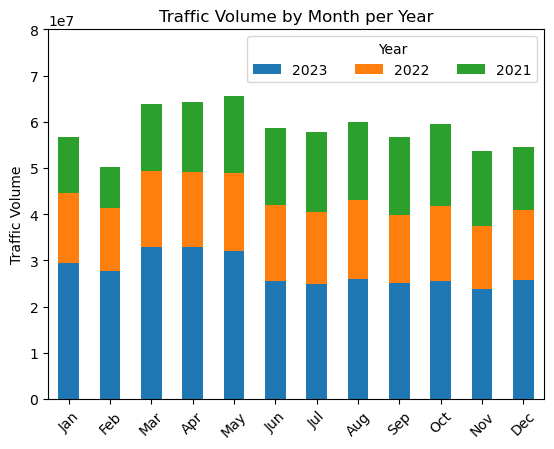

In [476]:
df_vol_by_month = austin_df \
    .groupby(['year_record', 'month_record'])['total_sum'] \
    .sum() \
    .reset_index()

df_pivot = df_vol_by_month \
    .pivot(index='month_record', columns='year_record', values='total_sum')

df_pivot.columns = ['2021', '2022', '2023']
df_pivot = df_pivot.sort_index(axis=1, ascending=False)
df_pivot.plot(kind='bar', stacked=True)

month_mapping = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

plt.title('Traffic Volume by Month per Year')
plt.ylabel('Traffic Volume')
plt.xlabel(None)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    title='Year', 
    handles=handles, 
    ncol=len(df_pivot),
    labels=[str(year) for year in df_pivot.columns]
)
plt.xticks(ticks=range(len(df_pivot)), labels=[month_mapping[i+1] for i in range(len(df_pivot))], rotation=45)
plt.ylim(0, 80000000)

plt.show()

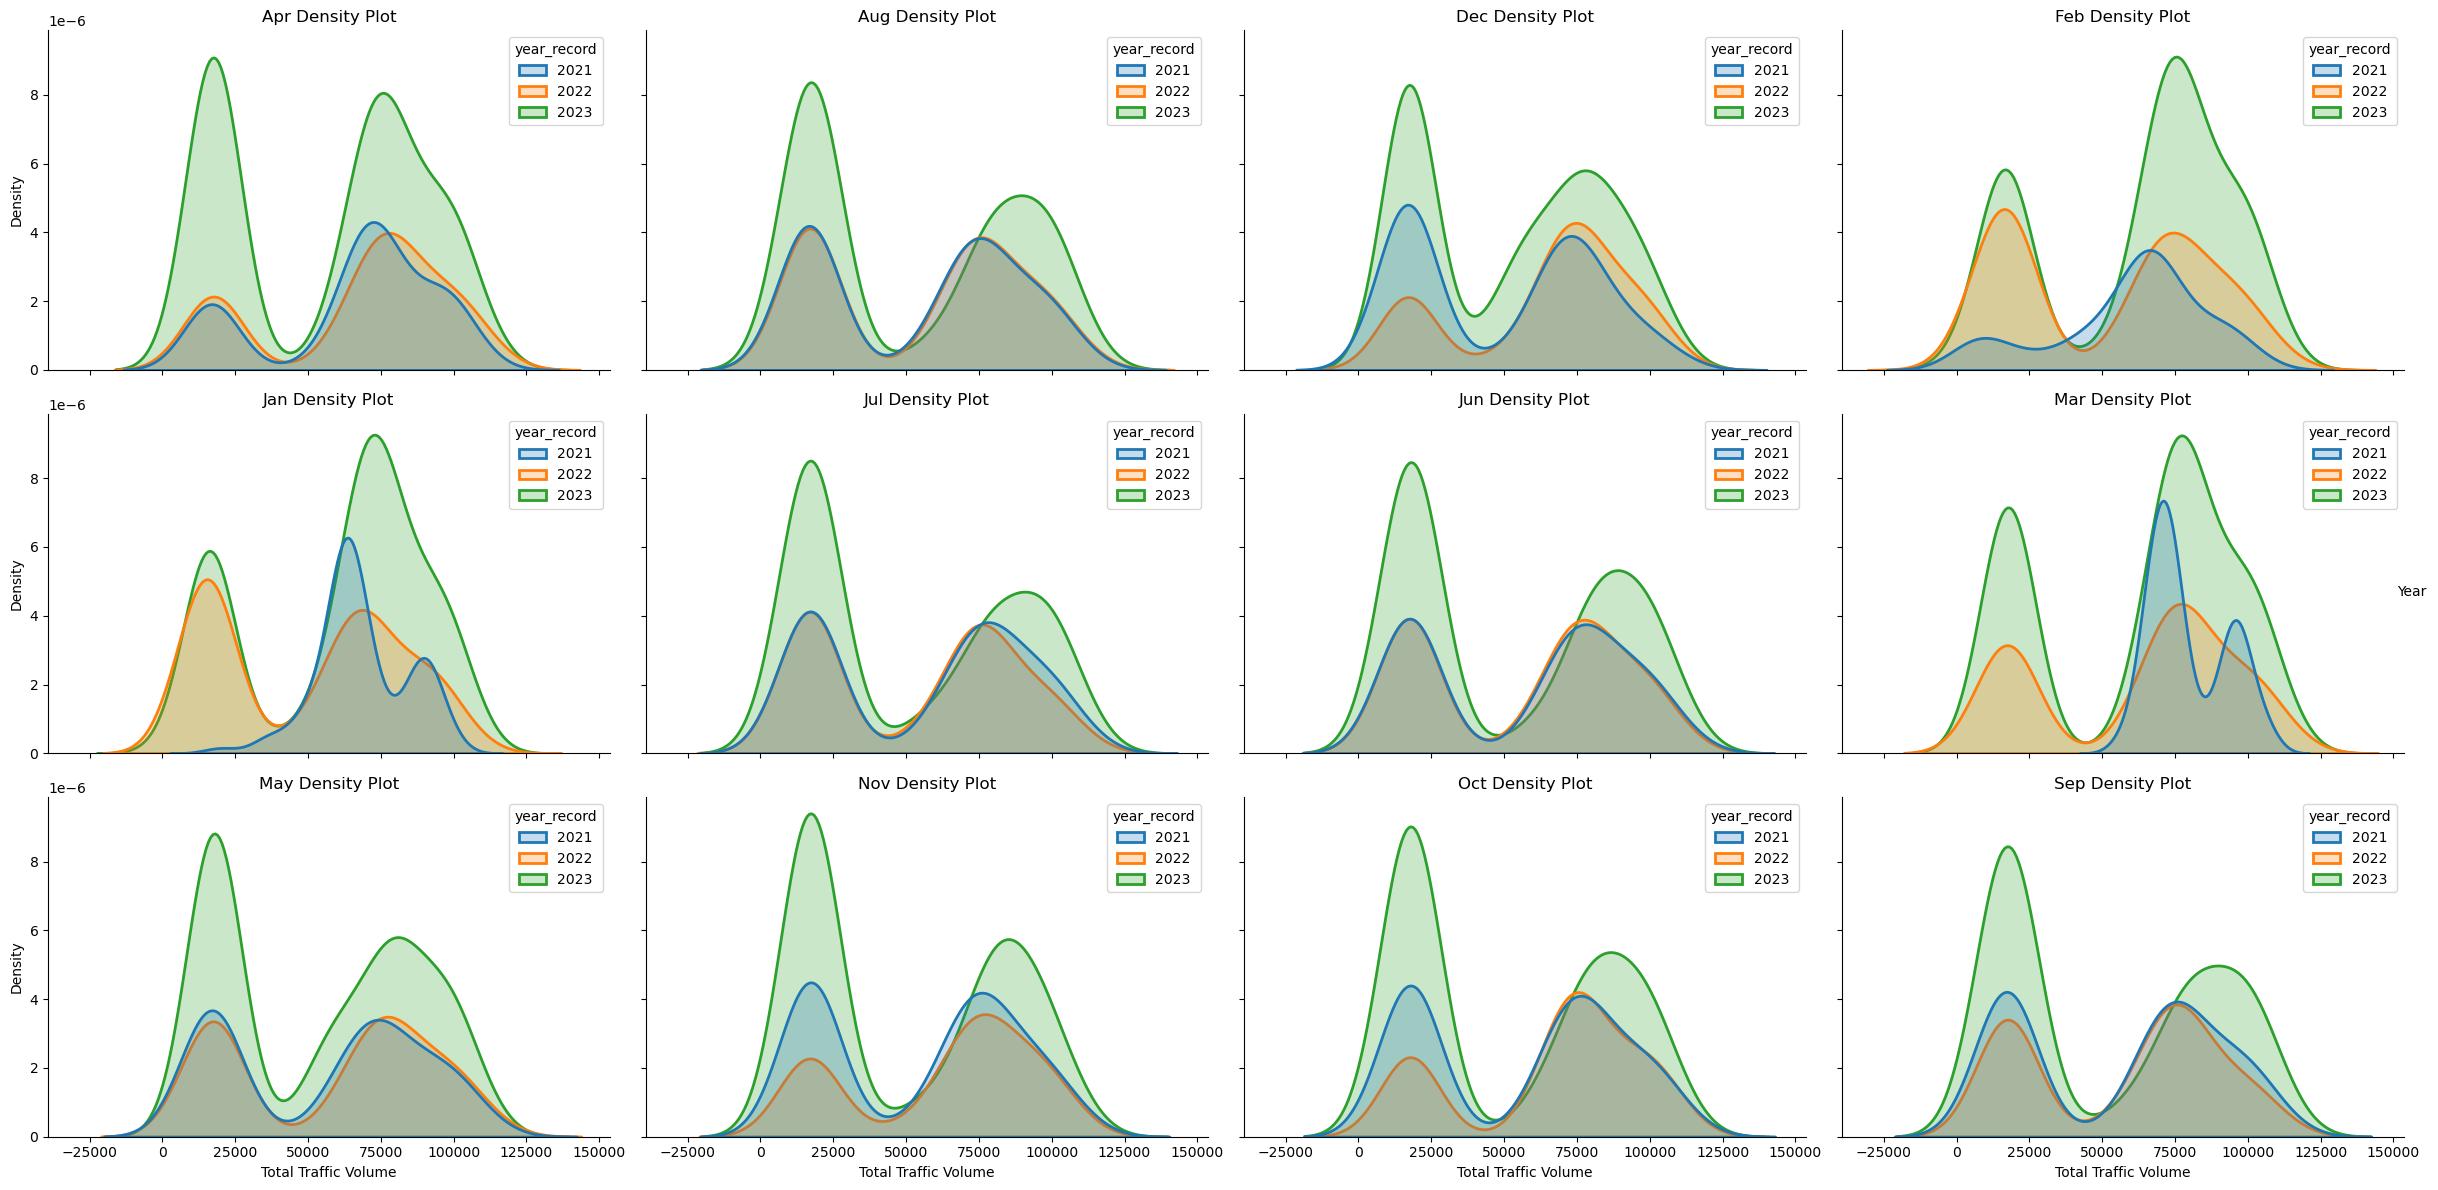

In [580]:
austin_df.loc[:, 'month_name'] = austin_df['month_record'].map(month_mapping)
austin_df.loc[:, 'year_record'] = austin_df['year_record'].apply(
    lambda x: f'20{x}' if len(str(x)) == 2 else str(x.strip())
)

g = sns.FacetGrid(austin_df, col="month_name", col_wrap=4, height=4, aspect=1.5)

for ax, month_name in zip(g.axes.flat, austin_df['month_name'].unique()):
    subset_data = austin_df[austin_df['month_name'] == month_name]
    sns.kdeplot(data=subset_data, x='total_sum', hue='year_record', fill=True, linewidth=2, ax=ax)
    ax.set_title(f"{month_name} Density Plot")

g.set_axis_labels("Total Traffic Volume", "Density")

g.add_legend(title="Year")
plt.tight_layout()

plt.show()

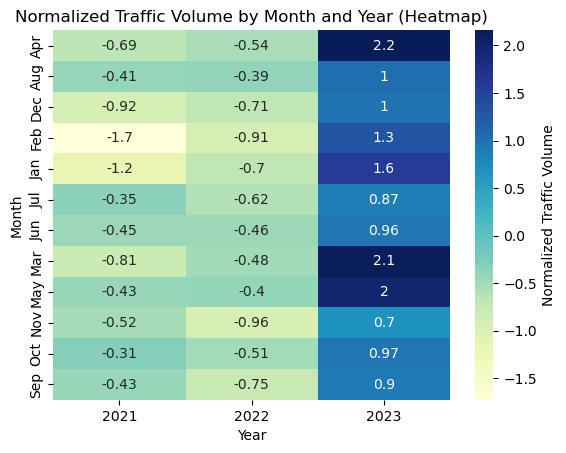

In [670]:
df_pivot = df_vol_by_month.pivot(index='month_name', columns='year_record', values='scaled_total_sum')

sns.heatmap(df_pivot, annot=True, cmap="YlGnBu", cbar_kws={'label': 'Normalized Traffic Volume'})

plt.title('Normalized Traffic Volume by Month and Year (Heatmap)')
plt.xlabel('Year')
plt.ylabel('Month')

plt.show()

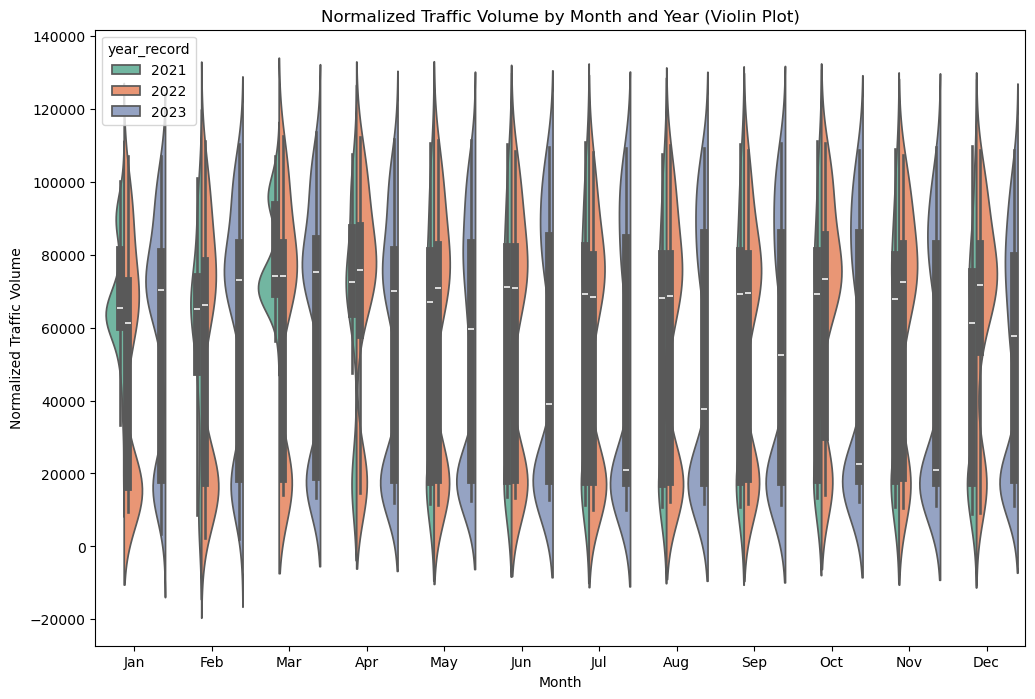

In [666]:
plt.figure(figsize=(12, 8))
sns.violinplot(data=austin_df, x='month_name', y='total_sum', hue='year_record', palette="Set2", order=list(month_mapping.values()), split=True)

plt.title('Normalized Traffic Volume by Month and Year (Violin Plot)')
plt.xlabel('Month')
plt.ylabel('Normalized Traffic Volume')

plt.show()